In model_comparison.ipynb, we saw that XGBoost was the winner. Here, we look closer at XGBoost's performance by going through the full hyperparameter + learning rate/num_boost_rounds tuning process, then evaluating its performance on a holdout set from each of the individual regions--Amazon rainforest, Siberian taiga, Borneo rainforest.

# Imports

In [1]:
import pandas as pd
import numpy as np

# Get and Format Data

In [2]:
def prepare_data(data, year):
    data = data.rename(columns=lambda x: x[2:] if x[1]=='_' else x)
    data['year'] = year
    data = data.sample(frac=1)
    return data

In [3]:
amazon_train_sets = [prepare_data(pd.read_csv(f"datasets/amazon_train_{year}.csv"), year) for year in range(2021, 2024)]
amazon_train = pd.concat(amazon_train_sets, axis=0)

taiga_train_sets = [prepare_data(pd.read_csv(f"datasets/taiga_train_{year}.csv"), year) for year in range(2021, 2024)]
taiga_train = pd.concat(taiga_train_sets, axis=0)

borneo_train_sets = [prepare_data(pd.read_csv(f"datasets/borneo_train_{year}.csv"), year) for year in range(2021, 2024)]
borneo_train = pd.concat(borneo_train_sets, axis=0)

train_set = pd.concat([amazon_train, taiga_train, borneo_train], axis=0)
train_set = train_set.sample(frac=1)
train_set = train_set.sort_values(by='year').reset_index()

In [4]:
all_features = train_set.columns.drop(['year', 'index', 'system:index', 'class', 'latitude', 'longitude', '.geo', 'year'])

In [5]:
from sklearn.model_selection import train_test_split

X = train_set[all_features]
y = train_set['class']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1)
print(X_train.head())
print(X_val.head())
print(y_val.head())

       NBR_delta_lag4  NBR_lag4  NDMI_delta_lag4  NDMI_lag4  NDVI_delta_lag4  \
11425        0.013710  0.345275         0.006364   0.201801         0.015641   
15472        0.038967  0.258865         0.077691   0.208559         0.014675   
801          0.237297  0.361925         0.269761   0.268507         0.222980   
1649         0.021566  0.340453         0.019899   0.209082         0.022602   
16470        0.055376  0.286209         0.077382   0.183334         0.043138   

       NDVI_lag4  SR_B4_delta_lag4  SR_B4_lag4  SR_B5_delta_lag4  SR_B5_lag4  \
11425   0.394589              25.0      8167.0             735.0     18813.0   
15472   0.252627            -152.0      9992.0             268.0     16747.0   
801     0.380751           -2110.0      8321.0            4214.5     18553.5   
1649    0.376144            -162.5      8165.5             575.0     18012.0   
16470   0.330488           -1568.5      8314.0           -1330.0     16522.0   

       ...  NDVI_delta_lag1  NDVI_lag1

In [6]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from xgboost import XGBClassifier
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

In [7]:
xgboost_param_grid = {
    'model__max_depth': Integer(3, 5),
    'model__min_child_weight': Integer (1, 200),
    'model__subsample': Real(0.7, 1),
    'model__colsample_bylevel': Real(0.5, 1),
    'model__colsample_bynode': Real(0.5, 1),
    'model__reg_lambda': Real(0, 10),
    'model__reg_alpha': Real(0, 10)
}

In [8]:
stage_1_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', XGBClassifier(objective='binary:logistic', random_state=1, learning_rate=0.3, tree_method='hist'))])

tuner = BayesSearchCV(
    estimator=stage_1_pipe,
    cv=5,
    refit='f1',
    search_spaces=xgboost_param_grid,
    return_train_score=True,
    random_state=1,
    scoring='f1'
)

In [9]:
tuner.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,search_spaces,"{'model__colsample_bylevel': Real(low=0.5,...m='normalize'), 'model__colsample_bynode': Real(low=0.5,...m='normalize'), 'model__max_depth': Integer(low=3...m='normalize'), 'model__min_child_weight': Integer(low=1...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,50
,scoring,'f1'
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,'f1'
,cv,5


In [10]:
print(tuner.best_params_)
params = {k.replace('model__', ''): v for k, v in tuner.best_params_.items()}


OrderedDict({'model__colsample_bylevel': 0.6196701073955828, 'model__colsample_bynode': 0.9590480724580536, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__reg_alpha': 2.224844363626686, 'model__reg_lambda': 5.708956982998847, 'model__subsample': 0.8298805102429921})


In [13]:
stage_2_transformer = PowerTransformer('yeo-johnson')
stage_2_model = XGBClassifier(**params, objective='binary:logistic', random_state=1, learning_rate=0.001, early_stopping_rounds=50, eval_metric="logloss", tree_method='hist')

In [14]:
X_train_stage2 = stage_2_transformer.fit_transform(X_train)
X_val_stage2 = stage_2_transformer.transform(X_val)

stage_2_model.fit(
    X_train_stage2, y_train,
    eval_set=[(X_val_stage2, y_val)], # Required for early stopping
    verbose=True,                     # Shows progress
)

[0]	validation_0-logloss:0.69261
[1]	validation_0-logloss:0.69206
[2]	validation_0-logloss:0.69151
[3]	validation_0-logloss:0.69096
[4]	validation_0-logloss:0.69042
[5]	validation_0-logloss:0.68987
[6]	validation_0-logloss:0.68933
[7]	validation_0-logloss:0.68878
[8]	validation_0-logloss:0.68824
[9]	validation_0-logloss:0.68771
[10]	validation_0-logloss:0.68717
[11]	validation_0-logloss:0.68663
[12]	validation_0-logloss:0.68609
[13]	validation_0-logloss:0.68554
[14]	validation_0-logloss:0.68501
[15]	validation_0-logloss:0.68448
[16]	validation_0-logloss:0.68393
[17]	validation_0-logloss:0.68339
[18]	validation_0-logloss:0.68286
[19]	validation_0-logloss:0.68233
[20]	validation_0-logloss:0.68181
[21]	validation_0-logloss:0.68128
[22]	validation_0-logloss:0.68075
[23]	validation_0-logloss:0.68021
[24]	validation_0-logloss:0.67969
[25]	validation_0-logloss:0.67917
[26]	validation_0-logloss:0.67864
[27]	validation_0-logloss:0.67811
[28]	validation_0-logloss:0.67758
[29]	validation_0-loglos

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,0.6196701073955828
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,0.9590480724580536
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = x

In [15]:
best_round = stage_2_model.best_iteration
print(best_round)
print(stage_2_model.best_score)


99
0.6427306956480917


In [16]:
final_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', XGBClassifier(**params, objective='binary:logistic', random_state=1, learning_rate=0.001, n_estimators=best_round, tree_method='hist'))])
final_pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transformer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"method method: {'yeo-johnson', 'box-cox'}, default='yeo-johnson'The power transform method. Available methods are:- 'yeo-johnson' [1]_, works with positive and negative values- 'box-cox' [2]_, only works with strictly positive values",'yeo-johnson'
,"standardize standardize: bool, default=TrueSet to True to apply zero-mean, unit-variance normalization to thetransformed output.",True
,"copy copy: bool, default=TrueSet to False to perform inplace computation during transformation.",True
,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


In [19]:
print(f1_score(y, final_pipe.predict(X)))

0.8744115766839077


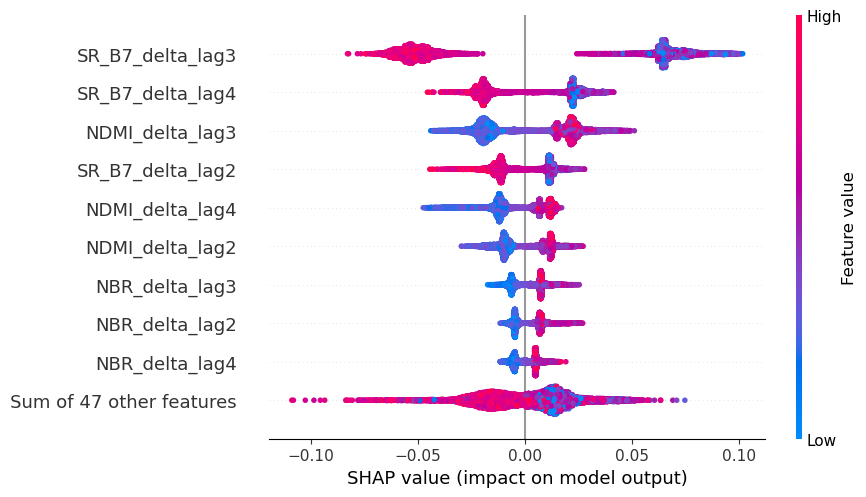

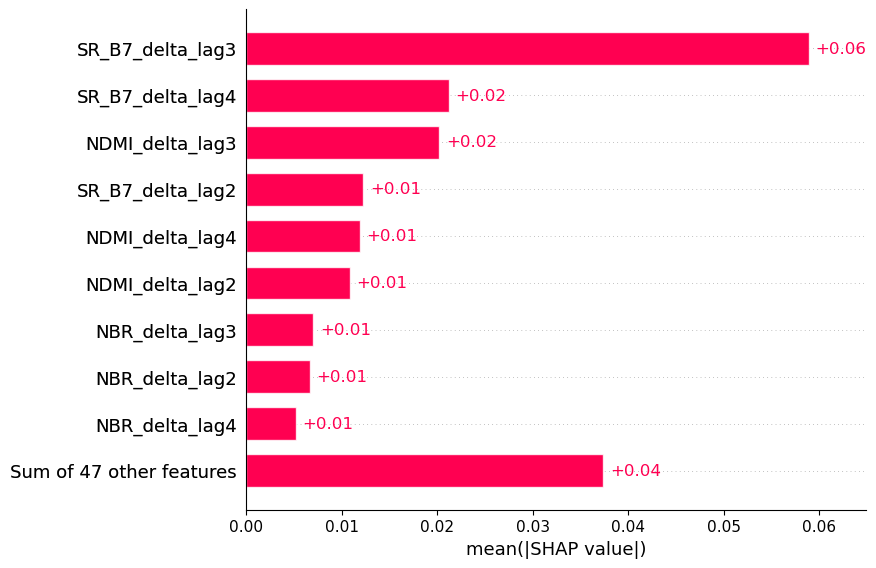

In [21]:
import shap
explainer = shap.Explainer(final_pipe['model'])
# Transform training data for the model component
X_trans = pd.DataFrame(
    final_pipe.named_steps['transformer'].transform(X_train),
    columns=all_features,
    index=X_train.index,
)
shap_values = explainer(X_trans)
# visualize explanations
shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)
